In [53]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict
from scipy.signal import resample, butter, filtfilt, iirnotch
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

In [54]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [55]:
def preprocess_eeg_trial(trial_matrix, original_sfreq=128, target_sfreq=128, target_length=256):
    
    if trial_matrix.shape[1] != target_length:
        trial_matrix = resample(trial_matrix, target_length, axis=1)

    nyquist = 0.5 * target_sfreq
    low_cut, high_cut = 1.0 / nyquist, 40.0 / nyquist
    b_band, a_band = butter(4, [low_cut, high_cut], btype='band')
    trial_matrix = filtfilt(b_band, a_band, trial_matrix, axis=1)

    for f in [50.0, 60.0]:
        b_notch, a_notch = iirnotch(w0=f, Q=30.0, fs=target_sfreq)
        trial_matrix = filtfilt(b_notch, a_notch, trial_matrix, axis=1)

    mean = trial_matrix.mean(axis=1, keepdims=True)
    std = trial_matrix.std(axis=1, keepdims=True) + 1e-8

    return (trial_matrix - mean) / std

In [56]:
class MindBigDataEPDataset(Dataset):
    def __init__(self, data, labels):
        self.data = torch.tensor(data, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

In [57]:
def find_data_file(root_path):
    for root, _, files in os.walk(root_path):
        for f in files:
            if f.endswith(".txt") or f.endswith(".csv"):
                return os.path.join(root, f)
    raise ValueError("No valid data file found!")

In [58]:
def get_scaled_dataset(file_path, target_length=256):

    print(f"[*] Searching dataset inside: {file_path}")

    if os.path.isdir(file_path):
        file_path = find_data_file(file_path)
        print(f"[+] Found data file: {file_path}")

    trials = defaultdict(dict)
    trial_labels = {}

    channel_map = {
        'AF3': 0, 'F7': 1, 'F3': 2, 'FC5': 3, 'T7': 4, 'P7': 5, 'O1': 6,
        'O2': 7, 'P8': 8, 'T8': 9, 'FC6': 10, 'F4': 11, 'F8': 12, 'AF4': 13
    }


    require_digit = [0, 1, 4, 5]

    label_map = {old: new for new, old in enumerate(require_digit)}

    with open(file_path, 'r') as f:
        for line in f:
            if not line.strip() or line.startswith('#'):
                continue

            parts = line.strip().split('\t')
            if len(parts) < 7:
                continue

            event_id = parts[1]
            channel_name = parts[3]
            digit = int(parts[4])
            signal_str = parts[6]

            
            if digit not in require_digit:
                continue

            ch_idx = channel_map.get(channel_name)
            if ch_idx is None:
                continue

            signal = np.fromstring(signal_str, sep=',')

            trials[event_id][ch_idx] = signal

            trial_labels[event_id] = label_map[digit]

    X, y = [], []

    for event_id, channels in trials.items():

        if len(channels) == 14:

            max_len = max(len(sig) for sig in channels.values())

            trial_matrix = np.zeros((14, max_len), dtype=np.float32)

            for ch_idx, signal in channels.items():
                trial_matrix[ch_idx, :len(signal)] = signal

            processed = preprocess_eeg_trial(
                trial_matrix,
                target_length=target_length
            )

            X.append(processed)
            y.append(trial_labels[event_id])

    X = np.array(X)
    y = np.array(y)


    print(f"[+] Dataset loaded: {X.shape}")

    print("[+] Unique labels:", np.unique(y))
    assert y.min() >= 0
    assert y.max() < len(require_digit)

    return X, y

In [59]:
class EEGNeX_ATCNet_Model(nn.Module):
    def __init__(self, num_channels=14, num_classes=4):
        super().__init__()

        self.temporal_conv = nn.Conv2d(1, 32, (1, 31), padding=(0, 15))
        self.bn1 = nn.BatchNorm2d(32)

        self.spatial_conv = nn.Conv2d(32, 32, (num_channels, 1), groups=32)
        self.bn2 = nn.BatchNorm2d(32)

        self.project = nn.Conv2d(32, 64, 1)
        self.bn3 = nn.BatchNorm2d(64)

        self.pool = nn.AvgPool2d((1, 4))
        self.dropout = nn.Dropout(0.3)

        self.layer_norm = nn.LayerNorm(64)
        self.attn = nn.MultiheadAttention(64, 4, batch_first=True)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 64, 256),
            nn.ELU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = x.unsqueeze(1)

        x = F.elu(self.bn1(self.temporal_conv(x)))
        x = F.elu(self.bn2(self.spatial_conv(x)))
        x = F.elu(self.bn3(self.project(x)))

        x = self.pool(x)
        x = self.dropout(x)

        x = x.squeeze(2).permute(0, 2, 1)

        attn_in = self.layer_norm(x)
        attn_out, _ = self.attn(attn_in, attn_in, attn_in)
        x = x + attn_out

        return self.classifier(x)

In [60]:
def train(model, train_loader, val_loader, epochs=100, lr=1e-4, patience=20):
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                                            optimizer,
                                            mode='max',        
                                            factor=0.75,        
                                            patience=10
                                            )

    best_val_acc = 0
    patience_counter = 0
    best_model_state = None

    for epoch in range(epochs):
        model.train()

        train_loss = 0
        train_correct = 0
        train_total = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * x.size(0)

            _, preds = torch.max(outputs, 1)
            train_total += y.size(0)
            train_correct += (preds == y).sum().item()

        train_acc = 100 * train_correct / train_total
        train_loss = train_loss / train_total

    
        model.eval()

        val_correct = 0
        val_total = 0
        val_loss = 0

        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                outputs = model(x)
                loss = criterion(outputs, y)

                val_loss += loss.item() * x.size(0)

                _, preds = torch.max(outputs, 1)
                val_total += y.size(0)
                val_correct += (preds == y).sum().item()

        val_acc = 100 * val_correct / val_total
        val_loss = val_loss / val_total
        scheduler.step(val_acc)
        
    
        print(f"Epoch [{epoch+1}/{epochs}] | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
        
        # EARLY STOPPING LOGIC
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"\n[EARLY STOPPING] No improvement for {patience} epochs")
            break

   
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\n[+] Best model restored with Val Acc: {best_val_acc:.2f}%")

    return model


In [61]:
def evaluate_model(model, val_loader):
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()

    all_preds = []
    all_true = []

    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_true.extend(y.cpu().numpy())

            correct += (preds == y).sum().item()
            total += y.size(0)

    accuracy = 100 * correct / total
    f1 = f1_score(all_true, all_preds, average='macro')

    print("\n" + "="*50)
    print(f"[EVAL] Accuracy: {accuracy:.2f}%")
    print(f"[EVAL] Macro F1: {f1:.4f}")
    print("="*50)

    return all_true, all_preds


In [62]:
def plot_confusion_matrix(y_true, y_pred):
    
    original_labels = [0, 1, 4, 5]

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=original_labels,
        yticklabels=original_labels
    )

    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

In [63]:
class ATCNet_LSTM(nn.Module):
    def __init__(self, n_channels=14, n_times=256, 
                 num_classes=4, hidden=256):
        super().__init__()
        
        self.spatial = nn.Sequential(
            nn.Conv2d(1, 16, (n_channels, 1)),  
            nn.BatchNorm2d(16),
            nn.ELU(),
            nn.Dropout(0.25)
        )
        
        self.temporal = nn.Sequential(
            nn.Conv1d(16, 32, kernel_size=25, padding=12),
            nn.BatchNorm1d(32),
            nn.ELU(),
            nn.AvgPool1d(8),
            nn.Dropout(0.25),
            nn.Conv1d(32, 64, kernel_size=15, padding=7),
            nn.BatchNorm1d(64),
            nn.ELU(),
            nn.AvgPool1d(4),
            nn.Dropout(0.25)
        )
        
        self.attention = nn.MultiheadAttention(
            embed_dim=64,
            num_heads=8,
            dropout=0.25,
            batch_first=True
        )
        self.attn_norm = nn.LayerNorm(64)
        
        self.lstm = nn.LSTM(
            input_size=64,
            hidden_size=hidden,
            num_layers=2,
            batch_first=True,
            dropout=0.3,
            bidirectional=True
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(hidden * 2, 256),
            nn.ELU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ELU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # x: (B, C, T)
        B = x.size(0)
        
        x = x.unsqueeze(1)              # (B, 1, C, T)
        x = self.spatial(x)             # (B, 16, 1, T)
        x = x.squeeze(2)                # (B, 16, T)
        
        x = self.temporal(x)            # (B, 64, T')
        
        x = x.permute(0, 2, 1)         # (B, T', 64)
        attn_out, _ = self.attention(x, x, x)
        x = self.attn_norm(x + attn_out) 
        
        out, _ = self.lstm(x)           # (B, T', hidden*2)
        out = out[:, -1, :]            
        
        return self.classifier(out)


In [64]:
import numpy as np
from collections import Counter

def augment_eeg(X, y, target_classes=[0, 1, 2, 3], noise_std=0.05, shift_max=10):
    """
    Data augmentation for specific EEG classes.
    target_classes: remapped labels (0→0, 1→1, 4→2)
    """
    X_aug = list(X)
    y_aug = list(y)

    class_counts = Counter(y)
    max_count = max(class_counts.values())

    for cls in target_classes:
        cls_indices = np.where(y == cls)[0]
        current_count = len(cls_indices)
        needed = max_count - current_count

        print(f"[*] Class {cls}: {current_count} samples → adding {needed} augmented samples")

        for i in range(needed):
            idx = cls_indices[i % current_count]
            sample = X[idx].copy() 

            # 1. Gaussian Noise
            noise = np.random.normal(0, noise_std, sample.shape)
            sample = sample + noise

            # 2. Time Shifting
            shift = np.random.randint(-shift_max, shift_max)
            sample = np.roll(sample, shift, axis=1)

            # 3. Channel Dropout
            drop_ch = np.random.randint(0, 14)
            sample[drop_ch, :] = 0

            X_aug.append(sample)
            y_aug.append(cls)

    X_aug = np.array(X_aug, dtype=np.float32)
    y_aug = np.array(y_aug, dtype=np.int64)

    indices = np.random.permutation(len(y_aug))
    return X_aug[indices], y_aug[indices]


In [65]:
DATASET_PATH = "/kaggle/input/datasets/vijayveersingh/1-2m-brain-signal-data/MindBigData-EP-v1.0"

X, y = get_scaled_dataset(DATASET_PATH)

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train_aug, y_train_aug = augment_eeg(
    X_train, y_train,
    target_classes=[1, 2],  # remapped:  1→1, 4→2
    noise_std=0.05,
    shift_max=10
)

print("[+] Train:", X_train_aug.shape, y_train_aug.shape)
print("[+] Val  :", X_val.shape, y_val.shape)

lenx = len(X)
leny = len(y)

train_ds = MindBigDataEPDataset(X_train_aug, y_train_aug)
val_ds   = MindBigDataEPDataset(X[:lenx//5], y[:leny//5])

train_loader = DataLoader(
    train_ds,
    batch_size=512,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=512,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

[*] Searching dataset inside: /kaggle/input/datasets/vijayveersingh/1-2m-brain-signal-data/MindBigData-EP-v1.0
[+] Found data file: /kaggle/input/datasets/vijayveersingh/1-2m-brain-signal-data/MindBigData-EP-v1.0/EP1.01.txt
[+] Dataset loaded: (25787, 14, 256)
[+] Unique labels: [0 1 2 3]
[*] Class 1: 6351 samples → adding 220 augmented samples
[*] Class 2: 6349 samples → adding 222 augmented samples
[+] Train: (26229, 14, 256) (26229,)


In [66]:
# model = EEGNeX_ATCNet_Model()
model = ATCNet_LSTM()
print("done")

done


In [67]:
train(model, train_loader, val_loader)

Epoch [1/100] | Train Loss: 1.3866 | Train Acc: 25.41% | Val Loss: 1.3862 | Val Acc: 24.96%
Epoch [2/100] | Train Loss: 1.3862 | Train Acc: 25.43% | Val Loss: 1.3858 | Val Acc: 25.13%
Epoch [3/100] | Train Loss: 1.3860 | Train Acc: 25.94% | Val Loss: 1.3851 | Val Acc: 26.47%
Epoch [4/100] | Train Loss: 1.3851 | Train Acc: 26.71% | Val Loss: 1.3837 | Val Acc: 26.95%
Epoch [5/100] | Train Loss: 1.3839 | Train Acc: 27.13% | Val Loss: 1.3816 | Val Acc: 27.79%
Epoch [6/100] | Train Loss: 1.3827 | Train Acc: 27.77% | Val Loss: 1.3779 | Val Acc: 28.89%
Epoch [7/100] | Train Loss: 1.3799 | Train Acc: 28.80% | Val Loss: 1.3725 | Val Acc: 30.21%
Epoch [8/100] | Train Loss: 1.3789 | Train Acc: 28.97% | Val Loss: 1.3715 | Val Acc: 30.19%
Epoch [9/100] | Train Loss: 1.3761 | Train Acc: 29.42% | Val Loss: 1.3645 | Val Acc: 31.69%
Epoch [10/100] | Train Loss: 1.3718 | Train Acc: 30.11% | Val Loss: 1.3564 | Val Acc: 32.83%
Epoch [11/100] | Train Loss: 1.3678 | Train Acc: 31.22% | Val Loss: 1.3532 | Va

ATCNet_LSTM(
  (spatial): Sequential(
    (0): Conv2d(1, 16, kernel_size=(14, 1), stride=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ELU(alpha=1.0)
    (3): Dropout(p=0.25, inplace=False)
  )
  (temporal): Sequential(
    (0): Conv1d(16, 32, kernel_size=(25,), stride=(1,), padding=(12,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ELU(alpha=1.0)
    (3): AvgPool1d(kernel_size=(8,), stride=(8,), padding=(0,))
    (4): Dropout(p=0.25, inplace=False)
    (5): Conv1d(32, 64, kernel_size=(15,), stride=(1,), padding=(7,))
    (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ELU(alpha=1.0)
    (8): AvgPool1d(kernel_size=(4,), stride=(4,), padding=(0,))
    (9): Dropout(p=0.25, inplace=False)
  )
  (attention): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
  )
  (attn_no


[EVAL] Accuracy: 55.54%
[EVAL] Macro F1: 0.5558


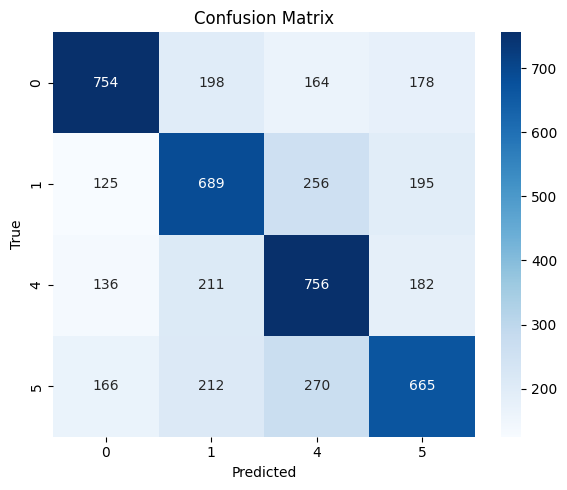

In [68]:
y_true, y_pred = evaluate_model(model, val_loader)

plot_confusion_matrix(y_true, y_pred)

In [70]:
torch.save(model.state_dict(), "digit_model_all.pth")
